In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [26]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [27]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [28]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data\quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


In [29]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================

# CELL 4.1 IMPORTS
import time
import random
from dataclasses import dataclass
import torch.nn.functional as F

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)





In [30]:
#CELL 4.2 Parameter Counter
def count_trainable_params(model) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def assert_param_limit(model, limit: int = 3_000_000):
    total = count_trainable_params(model)
    print(f"Trainable parameters: {total:,}")
    if total > limit:
        raise ValueError(f"Parameter limit exceeded: {total:,} > {limit:,}")
    return total

In [31]:
# CELL 4.3 MLP Builder
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        activation: str = "relu",
        dropout: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act_map = {
            "relu": nn.ReLU(),
            "leakyrelu": nn.LeakyReLU(0.1),
            "gelu": nn.GELU(),
            "tanh": nn.Tanh(),
        }
        if activation.lower() not in act_map:
            raise ValueError(f"Unsupported activation: {activation}")
        act = act_map[activation.lower()]

        layers = []
        prev = input_dim

        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act)
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, output_dim))  # logits output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten to [B,784]
        return self.net(x)

In [32]:
# CELL 4.4 Accuracy helper
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

In [33]:
#CELL 4.5 TRAIN 1 EPOCH
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        total_samples += bs

    return total_loss / total_samples, total_acc / total_samples

In [34]:
#CELL 4.6 Evaluate (validation)
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_samples = 0

    for X, y in loader:
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        total_samples += bs

    return total_loss / total_samples, total_acc / total_samples

In [35]:
#CELL 4.7 Fit loop, metric logging, checkpoint saving
def fit(
    model,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    weight_decay: float,
    device,
    save_path: str,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time_sec": [],
    }

    best_val_acc = -1.0
    best_epoch = -1

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        dt = time.time() - t0

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time_sec"].append(dt)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
            f"time {dt:.1f}s"
        )

        # Save best checkpoint by validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "best_val_acc": best_val_acc,
                    "best_epoch": best_epoch,
                },
                save_path,
            )

    print(f"\nBest val acc: {best_val_acc:.4f} at epoch {best_epoch}")
    return history, best_val_acc, best_epoch

In [36]:
#CELL 4.8 Plot curves utility 
def plot_history(history, title="Training Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " (Loss)")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " (Accuracy)")
    plt.legend()
    plt.show()

In [37]:
#CELL 4.9 FOLDER CREATION
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("submission", exist_ok=True)

# Part A — Pancake (Width Focus)

Trainable parameters: 1,638,415
Epoch 01/20 | train loss 1.1564 acc 0.6271 | val loss 0.9335 acc 0.7042 | time 7.8s
Epoch 02/20 | train loss 0.8239 acc 0.7354 | val loss 0.8749 acc 0.7210 | time 8.8s
Epoch 03/20 | train loss 0.6776 acc 0.7842 | val loss 0.7979 acc 0.7513 | time 8.3s
Epoch 04/20 | train loss 0.5670 acc 0.8175 | val loss 0.8039 acc 0.7464 | time 8.2s
Epoch 05/20 | train loss 0.4679 acc 0.8504 | val loss 0.7863 acc 0.7572 | time 7.8s
Epoch 06/20 | train loss 0.3752 acc 0.8795 | val loss 0.7881 acc 0.7631 | time 8.1s
Epoch 07/20 | train loss 0.2987 acc 0.9050 | val loss 0.8385 acc 0.7542 | time 8.9s
Epoch 08/20 | train loss 0.2276 acc 0.9304 | val loss 0.8629 acc 0.7582 | time 8.1s
Epoch 09/20 | train loss 0.1701 acc 0.9499 | val loss 0.8924 acc 0.7601 | time 8.0s
Epoch 10/20 | train loss 0.1222 acc 0.9684 | val loss 0.9238 acc 0.7588 | time 8.4s
Epoch 11/20 | train loss 0.0860 acc 0.9795 | val loss 0.9956 acc 0.7626 | time 7.9s
Epoch 12/20 | train loss 0.0600 acc 0.9876 |

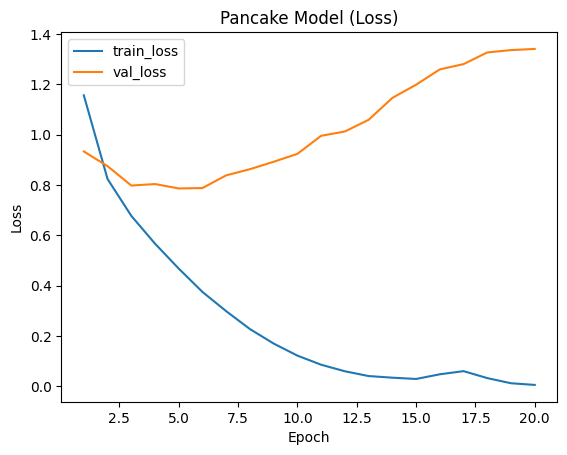

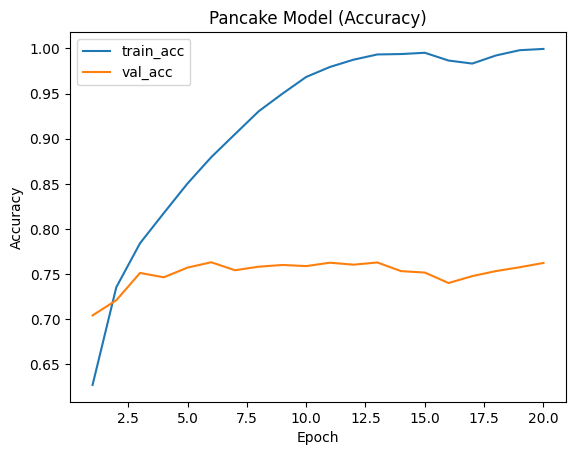

In [38]:
# ===============================
# Part A — Pancake Model (Wide & Shallow)
# ===============================

INPUT_DIM = 784
OUTPUT_DIM = NUM_CLASSES

# 1 hidden layer
hidden_dims = [2048]

pancake_model = MLP(
    input_dim=INPUT_DIM,
    hidden_dims=hidden_dims,
    output_dim=OUTPUT_DIM,
    activation="relu",
    dropout=0.0,
    use_batchnorm=False
)

params = assert_param_limit(pancake_model)

# Train
history_pancake, best_val_acc_pancake, best_epoch_pancake = fit(
    model=pancake_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,              
    lr=1e-3,
    weight_decay=0.0,
    device=DEVICE,
    save_path="models/pancake_best.pt"
)

plot_history(history_pancake, title="Pancake Model")

# Part B — Tower (Depth Focus)

Trainable parameters: 536,847
Epoch 01/30 | train loss 1.1253 acc 0.6280 | val loss 0.9003 acc 0.7033 | time 8.1s
Epoch 02/30 | train loss 0.8895 acc 0.7032 | val loss 0.8278 acc 0.7247 | time 8.0s
Epoch 03/30 | train loss 0.8113 acc 0.7267 | val loss 0.7737 acc 0.7441 | time 7.8s
Epoch 04/30 | train loss 0.7488 acc 0.7511 | val loss 0.7466 acc 0.7550 | time 8.4s
Epoch 05/30 | train loss 0.7125 acc 0.7621 | val loss 0.7343 acc 0.7563 | time 8.9s
Epoch 06/30 | train loss 0.6696 acc 0.7756 | val loss 0.7264 acc 0.7598 | time 8.4s
Epoch 07/30 | train loss 0.6416 acc 0.7867 | val loss 0.7267 acc 0.7585 | time 8.1s
Epoch 08/30 | train loss 0.6113 acc 0.7970 | val loss 0.7277 acc 0.7580 | time 11.0s
Epoch 09/30 | train loss 0.5806 acc 0.8070 | val loss 0.6979 acc 0.7720 | time 9.6s
Epoch 10/30 | train loss 0.5613 acc 0.8116 | val loss 0.7071 acc 0.7704 | time 9.1s
Epoch 11/30 | train loss 0.5385 acc 0.8221 | val loss 0.7140 acc 0.7700 | time 10.3s
Epoch 12/30 | train loss 0.5236 acc 0.8248 |

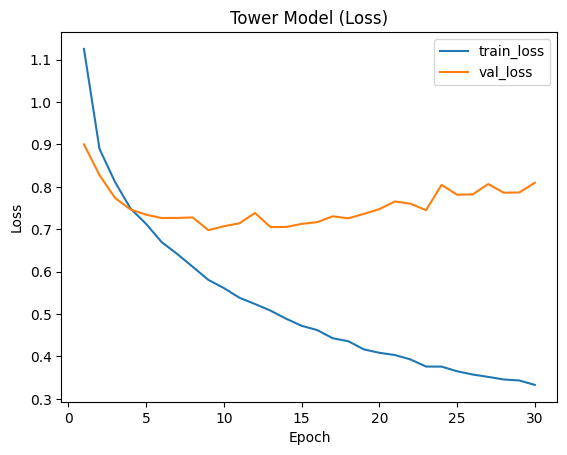

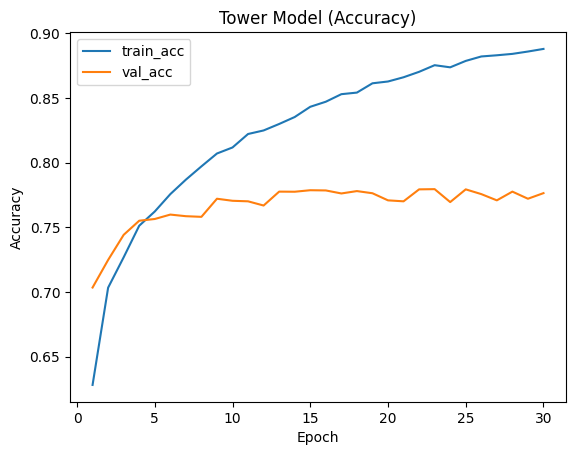

In [41]:
# ===============================
# Part B — Tower Model (Deep & Narrow)
# ===============================

INPUT_DIM = 784
OUTPUT_DIM = NUM_CLASSES

# 6 hidden layers, narrow width
hidden_dims = [256, 256, 256, 256, 256, 256]

tower_model = MLP(
    input_dim=INPUT_DIM,
    hidden_dims=hidden_dims,
    output_dim=OUTPUT_DIM,
    activation="leakyrelu",     
    dropout=0.1,                
    use_batchnorm=True          
)


params_tower = assert_param_limit(tower_model)

# Train
history_tower, best_val_acc_tower, best_epoch_tower = fit(
    model=tower_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,                 
    lr=1e-3,
    weight_decay=1e-4,         
    device=DEVICE,
    save_path="models/tower_best.pt"
)

plot_history(history_tower, title="Tower Model")

# Part C — Champion (Leaderboard Model)

Trainable parameters: 899,855
Epoch 01/30 | train loss 1.1896 acc 0.6133 | val loss 0.8808 acc 0.7059 | time 11.8s
Epoch 02/30 | train loss 0.9110 acc 0.6983 | val loss 0.8156 acc 0.7291 | time 9.7s
Epoch 03/30 | train loss 0.8287 acc 0.7268 | val loss 0.7654 acc 0.7440 | time 9.8s
Epoch 04/30 | train loss 0.7738 acc 0.7452 | val loss 0.7418 acc 0.7535 | time 10.2s
Epoch 05/30 | train loss 0.7372 acc 0.7557 | val loss 0.7224 acc 0.7602 | time 10.7s
Epoch 06/30 | train loss 0.6991 acc 0.7706 | val loss 0.7196 acc 0.7677 | time 10.5s
Epoch 07/30 | train loss 0.6783 acc 0.7767 | val loss 0.7145 acc 0.7656 | time 10.6s
Epoch 08/30 | train loss 0.6528 acc 0.7854 | val loss 0.6816 acc 0.7728 | time 10.5s
Epoch 09/30 | train loss 0.6412 acc 0.7899 | val loss 0.6842 acc 0.7740 | time 10.9s
Epoch 10/30 | train loss 0.6267 acc 0.7917 | val loss 0.6984 acc 0.7634 | time 10.8s
Epoch 11/30 | train loss 0.6073 acc 0.8001 | val loss 0.6939 acc 0.7737 | time 10.2s
Epoch 12/30 | train loss 0.5950 acc 0

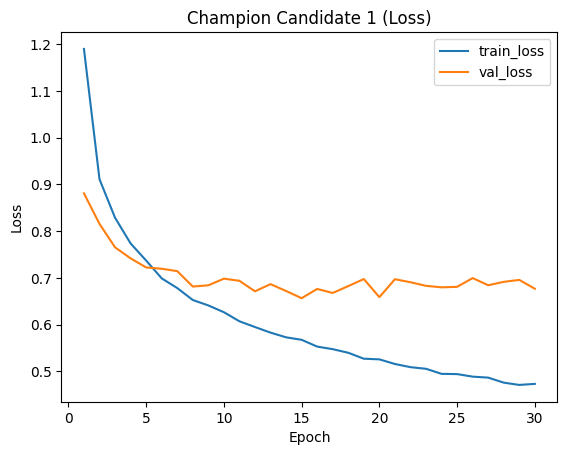

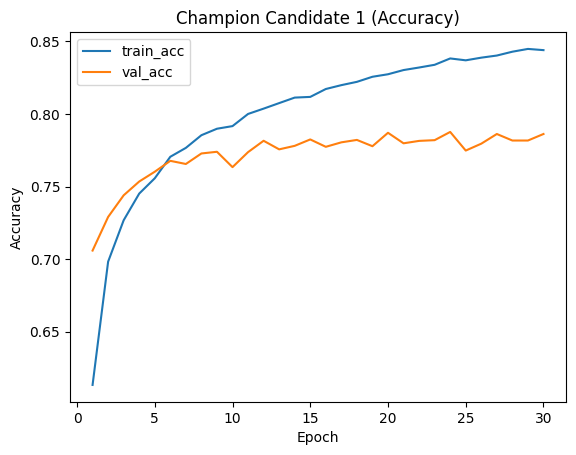

Champion Candidate 1 | params: 899855 | best_val_acc: 0.7876666668256124 | best_epoch: 24


In [42]:
# ===============================
# Part C — Champion Model candidate 1
# wider early, narrower later
# ===============================

INPUT_DIM = 784
OUTPUT_DIM = NUM_CLASSES

hidden_dims = [512, 512, 256, 256, 128] 

champ_model_1 = MLP(
    input_dim=INPUT_DIM,
    hidden_dims=hidden_dims,
    output_dim=OUTPUT_DIM,
    activation="gelu",          
    dropout=0.25,               
    use_batchnorm=True
)

params_ch1 = assert_param_limit(champ_model_1)

history_ch1, best_val_acc_ch1, best_epoch_ch1 = fit(
    model=champ_model_1,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,                  
    lr=1e-3,
    weight_decay=5e-4,          # stronger regularization
    device=DEVICE,
    save_path="models/champion_best.pt"
)

plot_history(history_ch1, title="Champion Candidate 1")
print("Champion Candidate 1 | params:", params_ch1, "| best_val_acc:", best_val_acc_ch1, "| best_epoch:", best_epoch_ch1)

### Candidate 1 Not selected due to higher params for similar accuracy

Trainable parameters: 717,583
Epoch 01/30 | train loss 1.2173 acc 0.6027 | val loss 0.8869 acc 0.7063 | time 13.5s
Epoch 02/30 | train loss 0.9249 acc 0.6949 | val loss 0.8091 acc 0.7309 | time 9.6s
Epoch 03/30 | train loss 0.8413 acc 0.7244 | val loss 0.7677 acc 0.7445 | time 9.3s
Epoch 04/30 | train loss 0.7807 acc 0.7430 | val loss 0.7611 acc 0.7458 | time 9.6s
Epoch 05/30 | train loss 0.7401 acc 0.7582 | val loss 0.7253 acc 0.7571 | time 10.3s
Epoch 06/30 | train loss 0.7076 acc 0.7664 | val loss 0.7120 acc 0.7660 | time 9.7s
Epoch 07/30 | train loss 0.6746 acc 0.7776 | val loss 0.7134 acc 0.7591 | time 10.0s
Epoch 08/30 | train loss 0.6440 acc 0.7890 | val loss 0.6984 acc 0.7651 | time 10.0s
Epoch 09/30 | train loss 0.6327 acc 0.7930 | val loss 0.6855 acc 0.7783 | time 9.6s
Epoch 10/30 | train loss 0.6134 acc 0.7971 | val loss 0.7095 acc 0.7669 | time 9.8s
Epoch 11/30 | train loss 0.5983 acc 0.8029 | val loss 0.7057 acc 0.7713 | time 10.0s
Epoch 12/30 | train loss 0.5838 acc 0.808

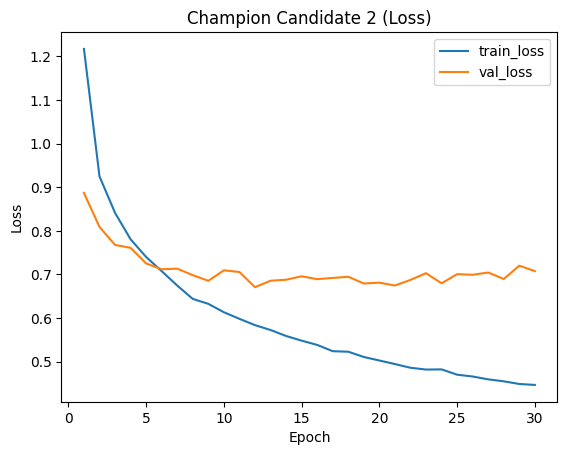

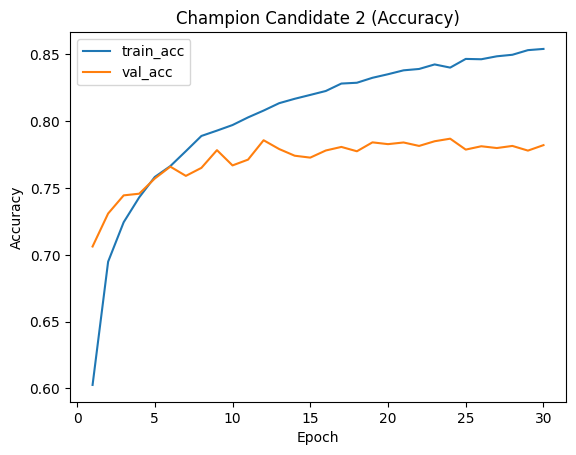

Champion Candidate 2 | params: 717583 | best_val_acc: 0.786916666507721 | best_epoch: 24


In [43]:
# ===============================
# Part C — Champion Model (Candidate 2)
# Efficient deep MLP, slight width bump
# ===============================

INPUT_DIM = 784
OUTPUT_DIM = NUM_CLASSES

hidden_dims = [384, 384, 256, 256, 256, 128]  # 6 hidden layers, still efficient

champ_model_2 = MLP(
    input_dim=INPUT_DIM,
    hidden_dims=hidden_dims,
    output_dim=OUTPUT_DIM,
    activation="gelu",
    dropout=0.2,
    use_batchnorm=True
)

params_ch2 = assert_param_limit(champ_model_2)

history_ch2, best_val_acc_ch2, best_epoch_ch2 = fit(
    model=champ_model_2,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    lr=1e-3,
    weight_decay=5e-4,
    device=DEVICE,
    save_path="models/champion2_best.pt"
)

plot_history(history_ch2, title="Champion Candidate 2")
print("Champion Candidate 2 | params:", params_ch2, "| best_val_acc:", best_val_acc_ch2, "| best_epoch:", best_epoch_ch2)

### Selected as final Champion

In [44]:
# ===============================
# Final Champion Selection: Candidate 2
# ===============================

final_hidden_dims = [384, 384, 256, 256, 256, 128]

final_model = MLP(
    input_dim=784,
    hidden_dims=final_hidden_dims,
    output_dim=NUM_CLASSES,
    activation="gelu",
    dropout=0.2,
    use_batchnorm=True
)

final_params = assert_param_limit(final_model)

ckpt = torch.load("models/champion2_best.pt", map_location=DEVICE)
final_model.load_state_dict(ckpt["model_state_dict"])

print("Loaded checkpoint with best_val_acc:", ckpt["best_val_acc"], "at epoch:", ckpt["best_epoch"])
print("FINAL CHAMPION | params:", final_params, "| best_epoch:", ckpt["best_epoch"])

Trainable parameters: 717,583
Loaded checkpoint with best_val_acc: 0.786916666507721 at epoch: 24
FINAL CHAMPION | params: 717583 | best_epoch: 24


# Part D — Theoretical Analysis

#### PART D — Question 1 --Width vs Depth Analysis

In [51]:
print("Pancake params:", count_trainable_params(pancake_model))
print("Tower params:", count_trainable_params(tower_model))

Pancake params: 1638415
Tower params: 536847


#### ANSWER 
Although the UAT guarantees that a single hidden layer MLP can approximate any continuous function,but it does not guarantee parameter efficiency.In practice, deep networks exploit the hierarchical structure of image data (edges → shapes → objects). 


Our Pancake model (1.64M params) achieved 76.31% validation accuracy and overfitted heavily, whereas the Tower model (536k parameters) achieved higher validation accuracy (77.94%) with significantly fewer parameters and better generalization. 
This suggests that depth provides representational efficiency and improved feature abstraction.

#### PART D — Question 2 --Confusion Matrix

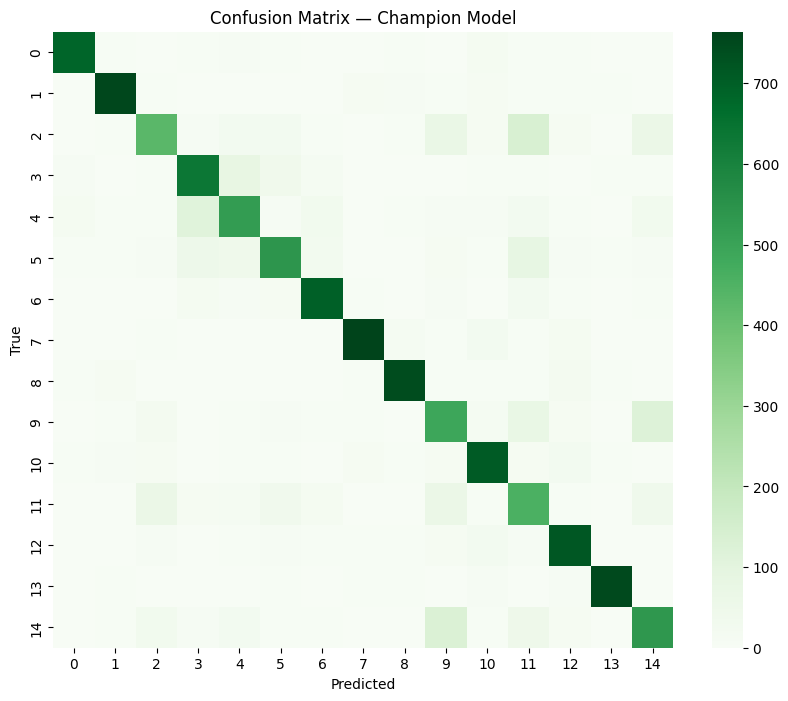

Top 2 confused class pairs (true → predicted):
basketball → soccerball : 138
wheel → pizza : 130


In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model = final_model
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(DEVICE)
        logits = model(X)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Greens")
plt.title("Confusion Matrix — Champion Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## find top 2 most confused pairs
import numpy as np

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# Get top 2 largest confusion entries
flat_indices = np.argsort(cm_no_diag.ravel())[::-1]

top2 = []
for idx in flat_indices:
    i = idx // cm.shape[1]
    j = idx % cm.shape[1]
    if cm_no_diag[i, j] > 0:
        top2.append((i, j, cm_no_diag[i, j]))
    if len(top2) == 2:
        break

print("Top 2 confused class pairs (true → predicted):")
for i, j, val in top2:
    print(f"{CLASSES[i]} → {CLASSES[j]} : {val}")

#### ASNWER 
In the confusion matrix, the most common mistakes happen between visually similar classes. The two most confused pairs are basketball -> soccerball (138 times) and wheel -> pizza (130 times).
These pairs make sense because they look very similar in simple doodle form. When someone draws them quickly, the details might not be clear, so the model can easily mix them up. Similarly, both wheel and pizza are circular objects. 


Since most of the mistakes happen between classes that look similar, and not randomly across all classes, this suggests that the problem is not mainly because the model is too weak. Instead, it is likely due to the nature of the dataset. 

The QuickDraw images are drawn very quickly and sometimes without clear details, so some level of confusion is expected even for humans. Therefore, these errors are more related to the ambiguity in the data rather than serious underfitting by the model.

# Part E — Report Material

#### ASNWER TO PART E ARE ATTACHED IN THE PDF DOCUMENT FILE WITH EXPLANTION

In [47]:

model = final_model
print("Model set for inference is ", type(model).__name__)

Model set for inference is  MLP


In [48]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data\quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [49]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 717,583
  ✅ Parameter count is within limits.
